In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

import phylograph as pg
import baselines as bl
from phylograph import affinity_kernel, distance_kernel
import seaborn as sns
import matplotlib.pyplot as plt
import os
sns.set_style("ticks",{"axes.facecolor":'white'})
sns.set_context("paper",font_scale=1.7)


ELEMENTS = ["MG_FE", "AL_FE", "SI_FE", "CA_FE", "TI_FE", "CR_FE", "NI_FE"]
# Nissen uses different column names for the same 7 elements:
ELEMENTS_NISSEN = ["Mg/Fe", "Al/Fe", "Si/Fe", "Ca/Fe", "Ti/Fe", "Cr/Fe", "Ni/Fe"]
c0, c1 = ((0.0, 0.537119244575752, 0.9817574744165642), (1.0, 0.0, 0.3283826208607874))
c2 = (0.0, 0.6, 0.3)
GRAPH_METRICS = ["ASD", "LSD", "NLSD"]   # LSD in the middle -> lands in the shaded band


In [2]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-18, License - CC BY-SA 4.0

import phylograph
import baselines
import imp

# Modify 'mymodule.py' externally...

imp.reload(phylograph)
imp.reload(bl)
imp.reload(baselines)
import phylograph as pg
import baselines as bl

/tmp/ipykernel_35124/2580263837.py:7: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [3]:

# ======================================================================
# 1. CLEANING  (the only per-run differences live here)
# ======================================================================

def clean_mw_gse():
    df_GES = pd.read_csv("data/sara/GES_members.csv")
    df_GES = df_GES[df_GES["FE_H_ERR"] < 0.03].reset_index(drop=True)
    df_mw = pd.read_csv("data/sara/MW.csv")
    df_mw = df_mw[df_mw["MG_FE"] < 0.9]
    df_mw = df_mw[df_mw["FE_H_ERR"] < 0.05]
    df_mw = df_mw[df_mw["FE_H"] <= df_GES["FE_H"].max() + 0.05]   # upper [Fe/H] cut to GSE max
    return df_mw.reset_index(drop=True), df_GES


def clean_mw_sgr():
    df_sgr = pd.read_csv("data/sara/sgr_apogee.csv")
    df_mw = pd.read_csv("data/sara/MW.csv")
    df_mw = df_mw[df_mw["MG_FE"] < 0.9]
    df_mw = df_mw[df_mw["FE_H_ERR"] < 0.05].reset_index(drop=True)
    # KDE reweighting: resample MW to the Sgr [Fe/H] density
    kde_sgr = gaussian_kde(df_sgr["FE_H"].dropna())
    kde_mw = gaussian_kde(df_mw["FE_H"].sample(n=min(50_000, len(df_mw)), random_state=0))
    p_sgr, p_mw = kde_sgr(df_mw["FE_H"]), kde_mw(df_mw["FE_H"])
    ratio = np.divide(p_sgr, p_mw, out=np.zeros_like(p_sgr), where=p_mw > 0)
    probs = ratio / ratio.max()
    df_mw = df_mw.sample(5 * len(df_sgr), weights=probs, random_state=0)
    return df_mw.reset_index(drop=True), df_sgr


def clean_gse_sgr():
    df_GES = pd.read_csv("data/sara/GES_members.csv")
    df_GES = df_GES[df_GES["FE_H_ERR"] < 0.03].reset_index(drop=True)
    df_sgr = pd.read_csv("data/sara/sgr_apogee.csv")
    # NOTE: comparable sizes -> no metallicity matching (matches the paper text)
    return df_GES, df_sgr


def clean_nissen():
    df = pd.read_csv("data/nissen20.csv")
    to_remove = (abs(df["Age"] - 5.8) < 0.7) & (abs(df["Fe/H"]) < 0.18)
    sep = (df["Fe/H"] > -0.1 * df["Age"] + 0.45).values
    df1 = df[~to_remove].copy()
    older = df1[sep[~to_remove]]
    younger = df1[~sep[~to_remove]]
    return older, younger


In [4]:
def load_clean():
    """Run all cleaning ONCE. Reuse the returned frames across many runs."""
    mw1, gse1 = clean_mw_gse()
    
    mw2, sgr2 = clean_mw_sgr()

    gse3, sgr3 = clean_gse_sgr()

    older, younger = clean_nissen()
    return dict(mw1=mw1, gse1=gse1, mw2=mw2, sgr2=sgr2,
                gse3=gse3, sgr3=sgr3, older=older, younger=younger)

F = load_clean()        

In [5]:
# ======================================================================
# 2. CONFIGS  (every parameter for every run, visible at a glance)
# ======================================================================


def build_configs(F, *, n_nodes=120, n_iterations=200, dist_ord=1,
                  weight_fn=None, clip_negative=True,
                  nissen_n_nodes=29, nissen_perturb=0.01):
    """Build configs from already-clean frames F. Cheap; call repeatedly
    with different parameters without re-cleaning."""
    wf = weight_fn if weight_fn is not None else affinity_kernel(1.0)
    common = dict(n_iterations=n_iterations, dist_ord=dist_ord,
                  weight_fn=wf, clip_negative=clip_negative)


    return [
        pg.RunConfig("MW-GSE", ("MW", F["mw1"]), ("GSE", F["gse1"]), ELEMENTS,
                     out_dir="data/history_trees", n_nodes=n_nodes, **common),
        pg.RunConfig("MW-Sgr", ("MW", F["mw2"]), ("Sgr", F["sgr2"]), ELEMENTS,
                     out_dir="data/history_trees", n_nodes=n_nodes, **common),
        pg.RunConfig("GSE-Sgr", ("GSE", F["gse3"]), ("Sgr", F["sgr3"]), ELEMENTS,
                     out_dir="data/history_trees", n_nodes=n_nodes, **common),
        pg.RunConfig("Nissen", ("Older", F["older"]), ("Younger", F["younger"]), ELEMENTS_NISSEN,
                     out_dir="data/nissen20_trees", n_nodes=nissen_n_nodes,
                     perturb_sigma=nissen_perturb, shared_base_intra=True, **common),
    ]

# Baseline run: each comparison gets its OWN directory so MW-MW from MW-GSE
# and MW-MW from MW-Sgr can't overwrite each other (they use differently
# reweighted MW frames). Nissen already has its own dir.
def build_configs_namespaced(F, **kw):
    cfgs = build_configs(F, **kw)
    for cfg in cfgs:
        if cfg.name != "Nissen":
            cfg.out_dir = f"data/history_trees/{cfg.name}"
    return cfgs

In [6]:
for cfg in build_configs_namespaced(F, weight_fn=affinity_kernel(sigma=.2), dist_ord=1):
    print(f"== {cfg.name} ==")
    bl.generate_trees_and_baselines(cfg)   # newick + *_abundance.csv (shared matrices)
    pg.compute_distances(cfg)              # spectral *_distances.csv from the same newick

== MW-GSE ==
[MW-GSE] MW: 3436 stars | GSE: 288 stars


== MW-Sgr ==
[MW-Sgr] MW: 2034 stars | Sgr: 354 stars
== GSE-Sgr ==
[GSE-Sgr] GSE: 288 stars | Sgr: 354 stars
== Nissen ==
[Nissen] Older: 41 stars | Younger: 29 stars


In [7]:
panels = {
    "GSE-Sgr": ("data/history_trees/GSE-Sgr", ["GSE-GSE", "Sgr-Sgr"], "GSE-Sgr"),
    "MW-GSE":  ("data/history_trees/MW-GSE",  ["MW-MW", "GSE-GSE"],   "MW-GSE"),
    "MW-Sgr":  ("data/history_trees/MW-Sgr",  ["MW-MW", "Sgr-Sgr"],   "MW-Sgr"),
    "Nissen":  ("data/nissen20_trees",        ["Older-Older", "Younger-Younger"], "Older-Younger"),
}

In [8]:
spec = pg.auc_table(panels, measures=("ASD", "LSD", "NLSD"), suffix="distances")
base = pg.auc_table(panels, measures=("ENERGY",), suffix="abundance")  # drop CENTROID — meaningless once centered, and you already have the uncentered version from before if you want it for contrast
full = pd.concat([base, spec]).reindex(["ENERGY", "ASD", "LSD", "NLSD"])
print(full.round(2))

panel    GSE-Sgr  MW-GSE  MW-Sgr  Nissen
measure                                 
ENERGY      1.00    1.00    1.00    1.00
ASD         1.00    1.00    0.62    0.70
LSD         1.00    1.00    0.64    0.98
NLSD        0.84    0.88    0.55    0.54


In [9]:
full_precision = pd.concat([base, spec]).reindex(["ENERGY", "ASD", "LSD", "NLSD"])
print(full_precision.to_string(float_format=lambda x: f"{x:.4f}"))

panel    GSE-Sgr  MW-GSE  MW-Sgr  Nissen
measure                                 
ENERGY    1.0000  1.0000  1.0000  1.0000
ASD       1.0000  1.0000  0.6237  0.6980
LSD       1.0000  1.0000  0.6369  0.9783
NLSD      0.8379  0.8807  0.5452  0.5421


In [10]:
from sklearn.metrics import roc_auc_score
import numpy as np, pandas as pd, os

def detail(d, intra_names, inter_name, col):
    intra = np.concatenate([pd.read_csv(f"{d}/{n}_abundance.csv")[col].values for n in intra_names])
    inter = pd.read_csv(f"{d}/{inter_name}_abundance.csv")[col].values
    auc = roc_auc_score(np.r_[np.zeros(len(intra)), np.ones(len(inter))], np.r_[intra, inter])
    viol = int((intra[:,None] >= inter[None,:]).sum())
    print(f"{inter_name:14s} {col:12s} AUC={auc:.6f}  viol={viol}/{len(intra)*len(inter)}  "
          f"intra[{intra.mean():.4f}±{intra.std():.4f}] inter[{inter.mean():.4f}±{inter.std():.4f}]")

for d, intra, inter in [
    ("data/history_trees/MW-Sgr", ["MW-MW","Sgr-Sgr"], "MW-Sgr"),
    ("data/nissen20_trees", ["Older-Older","Younger-Younger"], "Older-Younger"),
]:
    for col in ["CENTROID","ENERGY"]:   # add ENERGY_UNCTR/ENERGY_CTR if you split them
        detail(d, intra, inter, col)

MW-Sgr         CENTROID     AUC=1.000000  viol=0/80000  intra[0.0779±0.0318] inter[1.5527±0.0540]
MW-Sgr         ENERGY       AUC=0.999975  viol=2/80000  intra[0.0099±0.0042] inter[0.0547±0.0092]
Older-Younger  CENTROID     AUC=1.000000  viol=0/80000  intra[0.0146±0.0041] inter[0.2512±0.0169]
Older-Younger  ENERGY       AUC=1.000000  viol=0/80000  intra[0.0042±0.0007] inter[0.0264±0.0066]


sigma = 0.207
q50: sigma=0.109, min weight=1.85e-11
q75: sigma=0.207, min weight=2.33e-06
q90: sigma=0.368, min weight=6.74e-04


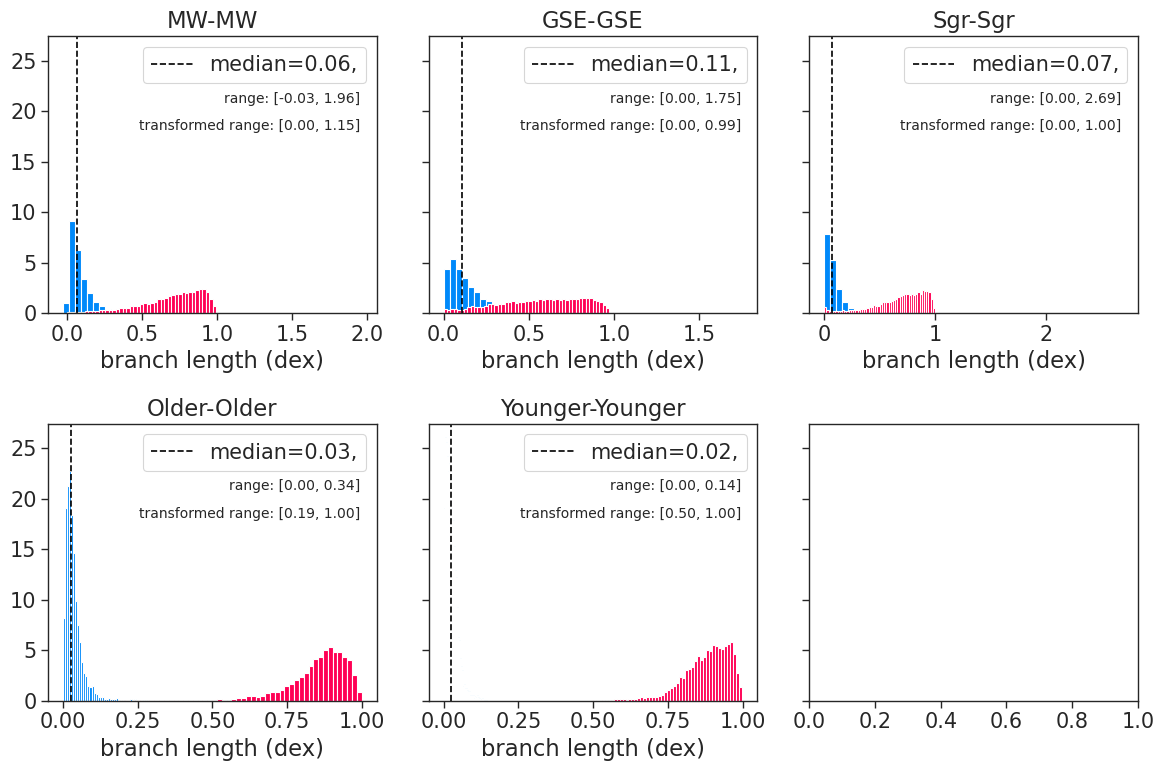

In [11]:
files = {
    "MW-MW":   "data/history_trees/MW-MW.newick",
    "GSE-GSE": "data/history_trees/GSE-GSE.newick",
    "Sgr-Sgr": "data/history_trees/Sgr-Sgr.newick",
    "Older-Older": "data/nissen20_trees/Older-Older.newick",
    "Younger-Younger": "data/nissen20_trees/Younger-Younger.newick",
}

fig, axes = plt.subplots(2,3, figsize=(12, 8), sharey=True)
all_lengths = np.concatenate([
    pg.branch_length_distribution(f"data/history_trees/{p}.newick")
    for p in ["MW-MW", "GSE-GSE", "Sgr-Sgr"]
])
sigma = float(np.median(all_lengths))
q75 = np.percentile(all_lengths, 75)
sigma = q75 / np.log(2)   # w=0.5 at the 75th percentile
print(f"sigma = {sigma:.3f}")


all_lengths = np.concatenate([
    pg.branch_length_distribution(f"data/history_trees/{p}.newick")
    for p in ["MW-MW", "GSE-GSE", "Sgr-Sgr"]
])
for q in [50, 75, 90]:
    s = np.percentile(all_lengths, q) / np.log(2)
    w_max = np.exp(-all_lengths.max() / s)
    print(f"q{q}: sigma={s:.3f}, min weight={w_max:.2e}")
    
ss=1/(sigma)



axes = axes.ravel()
for ax, (label, path) in zip(axes, files.items()):
    lengths = pg.branch_length_distribution(path)
    ax.hist(lengths, bins=50, color=c0, density=True)
    ax.hist(np.exp(-ss*lengths), bins=50, color=c1, density=True)
    ax.axvline(np.median(lengths), color="k", ls="--", label=f"median={np.median(lengths):.2f},")
    ax.text(0.95, 0.80, f"range: [{min(lengths):.2f}, {max(lengths):.2f}]", transform=ax.transAxes,
            ha="right", va="top", fontsize=10)
    ax.text(0.95, 0.70, f"transformed range: [{min(np.exp(-ss*lengths)):.2f}, {max(np.exp(-ss*lengths)):.2f}]", transform=ax.transAxes,
            ha="right", va="top", fontsize=10)   
    ax.set_title(label)
    ax.set_xlabel("branch length (dex)")
    ax.legend()

plt.tight_layout()



In [12]:
def _load_panel(d, pairs):
    parts = []
    for p in pairs:
        df = pd.read_csv(os.path.join(d, f"{p}_distances.csv")).melt(
            var_name="metric", value_name="distance")
        df["pair"] = p
        parts.append(df)
    long = pd.concat(parts, ignore_index=True)
    long["distance"] = long.groupby("metric")["distance"].transform(lambda v: v / v.max())
    return long[long.metric.isin(GRAPH_METRICS)]

def plot_four_panels(outfile="fourpanel_boxen.png"):
    panels = [
        ("MW–Sgr",  "data/history_trees",  ["MW-MW", "Sgr-Sgr", "MW-Sgr"]),
        ("GSE–Sgr", "data/history_trees",  ["GSE-GSE", "Sgr-Sgr", "GSE-Sgr"]),
        ("MW–GSE",  "data/history_trees",  ["MW-MW", "GSE-GSE", "MW-GSE"]),
        ("Nissen",  "data/nissen20_trees", ["Older-Older", "Younger-Younger", "Older-Younger"]),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(17,10), dpi=200,sharex=True, sharey=True)
    for (title, d, pairs), ax in zip(panels, axes.flat):
        long = _load_panel(d, pairs)
        sns.boxenplot(data=long, y="metric", x="distance", hue="pair",
                      order=GRAPH_METRICS, hue_order=pairs,
                      linewidth=.5, ax=ax, palette=[c0, c1, c2], alpha=.9)
        ax.axhspan(0.5, 1.5, color="grey", alpha=0.1, zorder=0)   # shades LSD (middle row)
        ax.set_ylabel("")
        ax.set_xlabel(r"$\tilde{M}$")
        ax.set_xlim(0, 1.01)
        ax.legend(title = "", loc = "lower left",frameon=1, ncol=1,labelspacing=.4,columnspacing=.7)

    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.02, wspace=0.03)
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    return fig



In [13]:
# AUC table across all panels
panels = {
    "MW-GSE":  ("data/history_trees", ["MW-MW", "GSE-GSE"], "MW-GSE"),
    "GSE-Sgr": ("data/history_trees", ["GSE-GSE", "Sgr-Sgr"], "GSE-Sgr"),
    "MW-Sgr":  ("data/history_trees", ["MW-MW", "Sgr-Sgr"], "MW-Sgr"),
    "Nissen":  ("data/nissen20_trees", ["Older-Older", "Younger-Younger"], "Older-Younger"),
}
print(pg.auc_table(panels).round(2))


panel    GSE-Sgr  MW-GSE  MW-Sgr  Nissen
measure                                 
ASD         1.00    1.00    0.62    0.70
LSD         1.00    1.00    0.64    0.98
NLSD        0.84    0.88    0.55    0.54


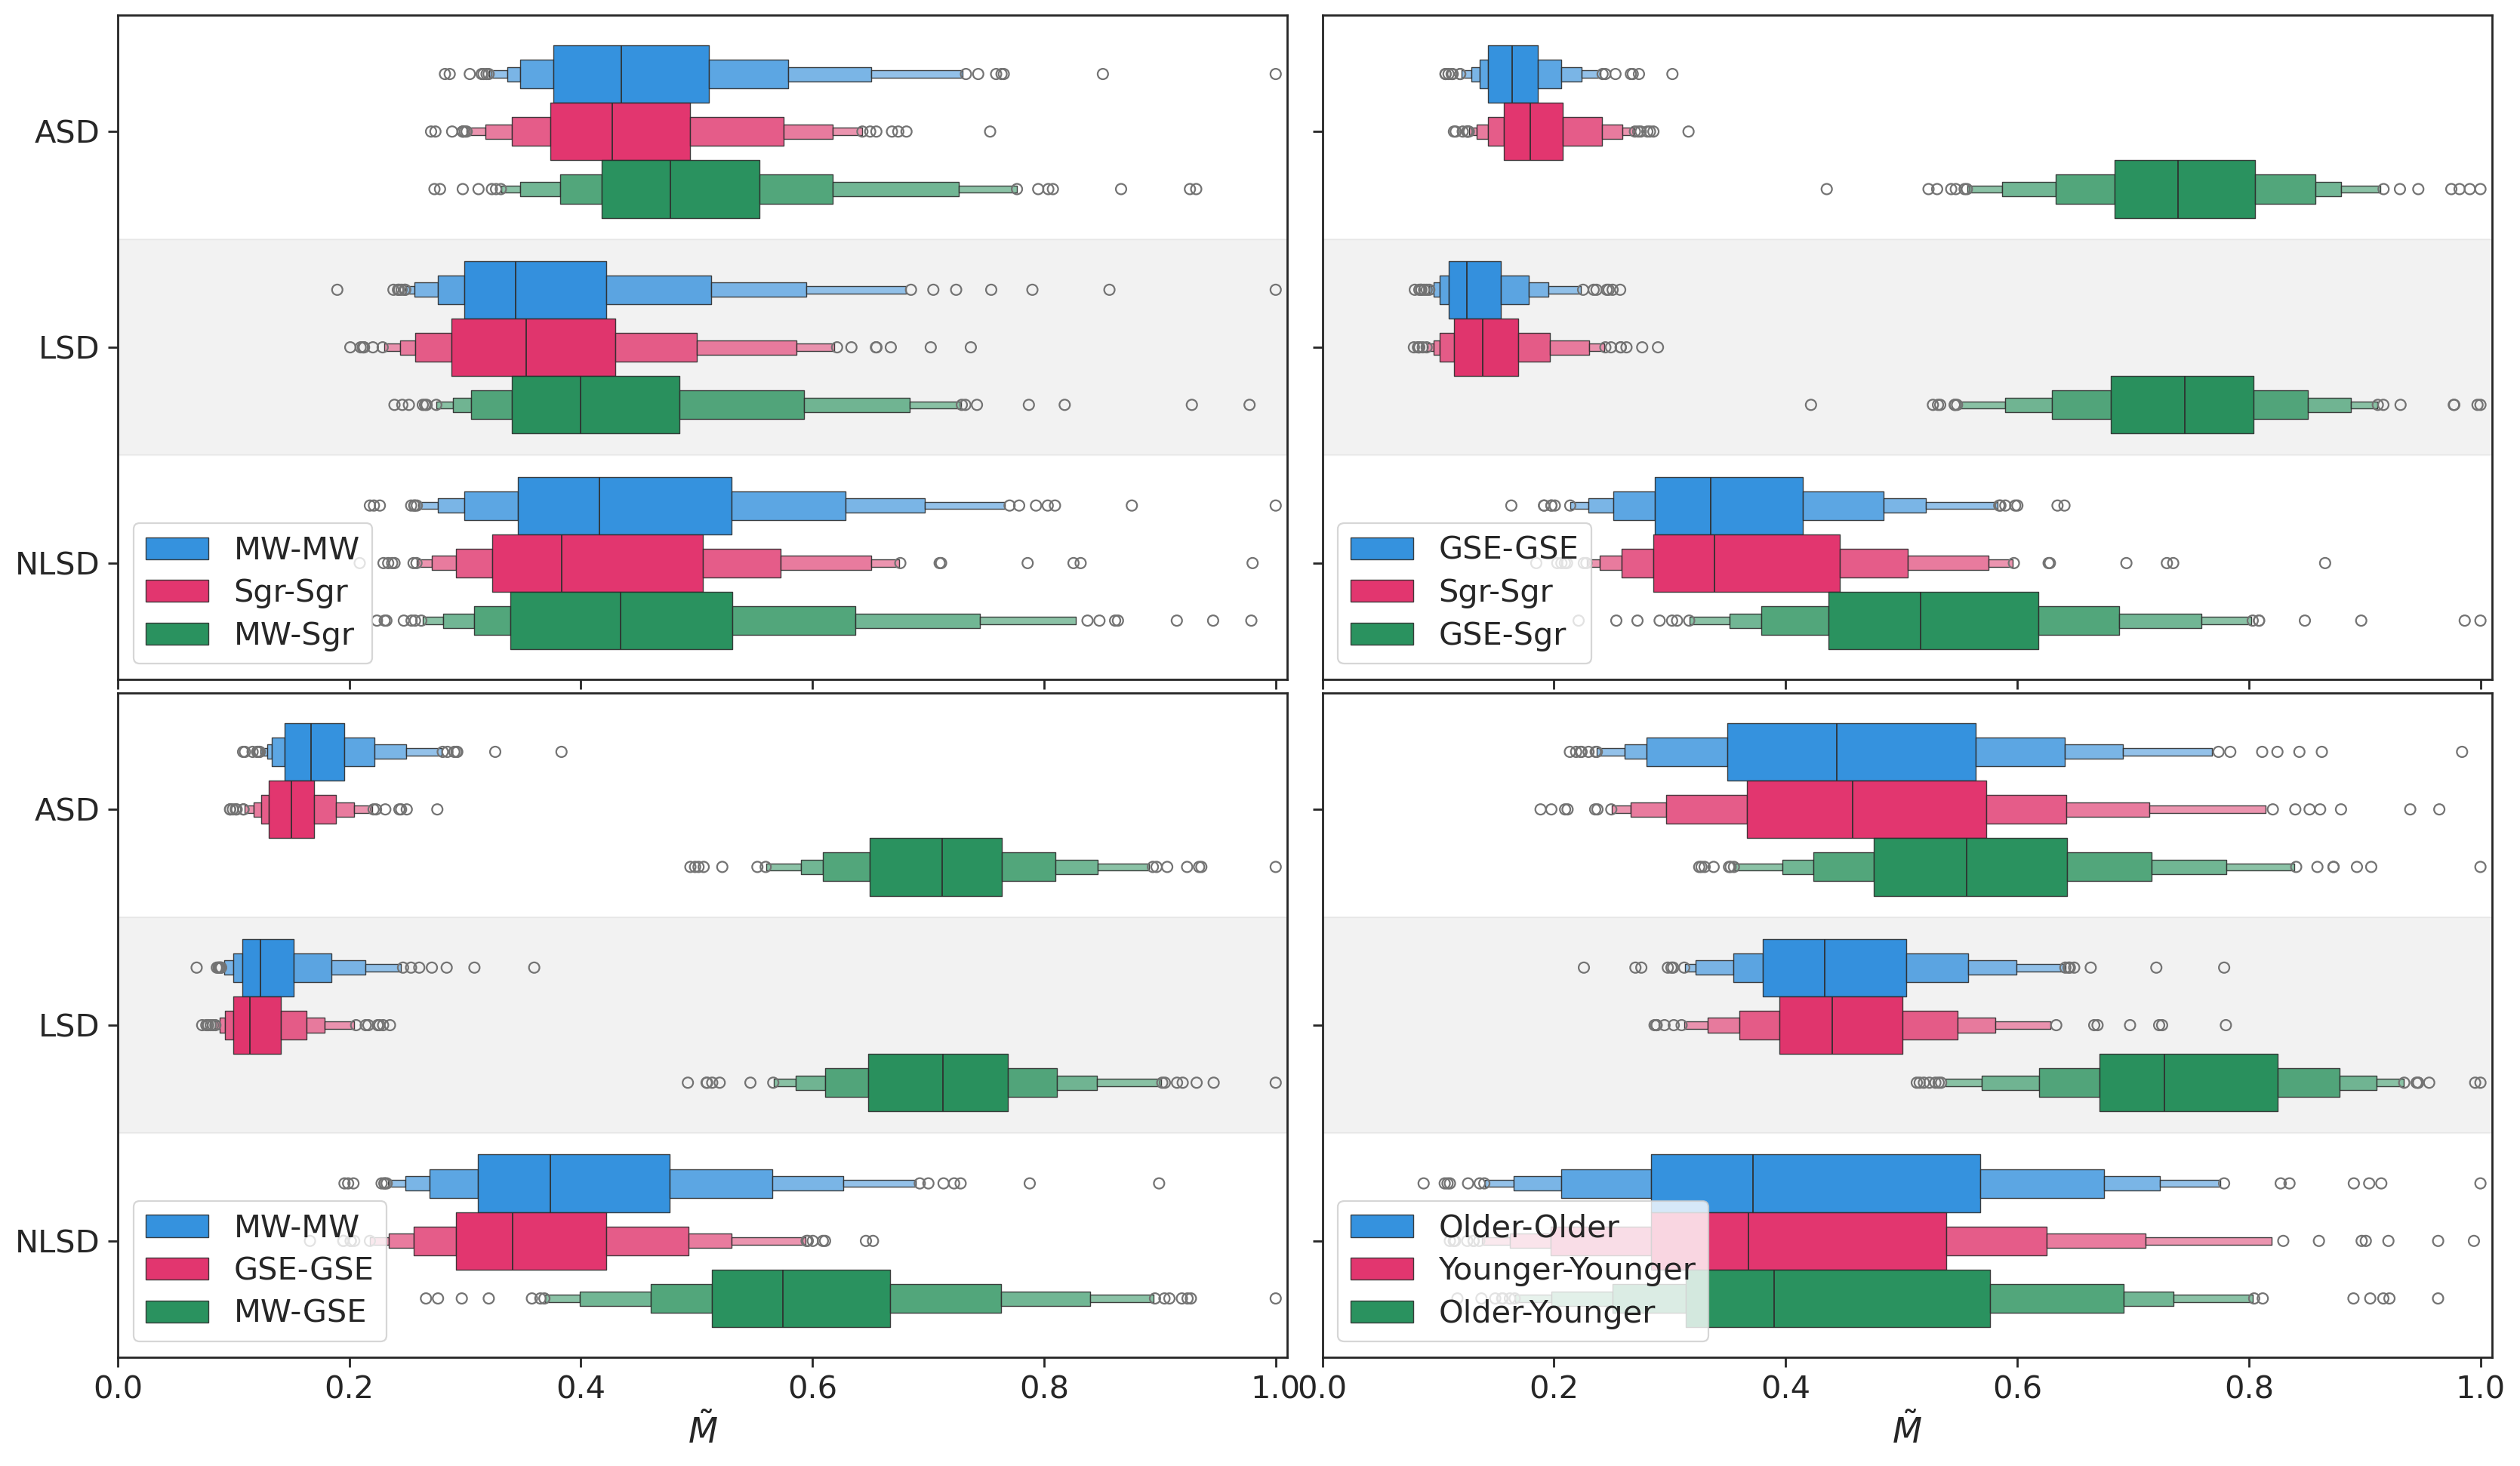

In [14]:
fig = plot_four_panels();

In [15]:
print(pg.auc_table_latex(panels))

\begin{table}
\caption{AUC values for the separation between intra- and
inter-population distance distributions.}
\label{tab:auc}
\centering
\begin{tabular}{lcccc}
\hline\hline
Measure & GSE--Sgr & MW--GSE & MW--Sgr & Nissen \\
\hline
ASD & 1.00 & 1.00 & 0.62 & 0.70 \\
LSD & 1.00 & 1.00 & 0.64 & 0.98 \\
NLSD & 0.84 & 0.88 & 0.55 & 0.54 \\


# [X/H] abundances

In [16]:
import abundances as ab
import imp; imp.reload(ab)

# --- choice of experiment -------------------------------------------------
# INCLUDE_FEH = True  -> 8 features (7 [X/H] + [Fe/H]); re-introduces the
#                        overall-metallicity axis that [X/Fe] removes.
#                        THIS is the run your email's prediction is about.
# INCLUDE_FEH = False -> 7 features ([X/H] only); pure change-of-reference test.
INCLUDE_FEH = False


In [17]:

def convert_frames_xh(F, *, include_feh=INCLUDE_FEH):
    """Return (F_xh, elem_apogee, elem_nissen): converted frames plus the
    element lists to hand RunConfig. Row-loss from [Fe/H] NaNs is reported
    per frame and happens HERE, identically for all populations."""
    F_xh = {}
    elem_apogee = elem_nissen = None
    for key, df in F.items():
        if key in ("older", "younger"):          # Nissen naming
            F_xh[key], cols = ab.nissen_to_xh(df, include_feh=include_feh, label=key)
            elem_nissen = cols
        else:                                     # APOGEE naming
            F_xh[key], cols = ab.apogee_to_xh(df, include_feh=include_feh, label=key)
            elem_apogee = cols
    return F_xh, elem_apogee, elem_nissen


F_xh, ELEM_XH, ELEM_XH_NISSEN = convert_frames_xh(F)
print("X/H element list (APOGEE):", ELEM_XH)
print("X/H element list (Nissen):", ELEM_XH_NISSEN)


[mw1] dropped 98 rows lacking [Fe/H] or an element (3436 remain)
[gse1] dropped 48 rows lacking [Fe/H] or an element (288 remain)
[mw2] dropped 56 rows lacking [Fe/H] or an element (2034 remain)
[sgr2] dropped 64 rows lacking [Fe/H] or an element (354 remain)
[gse3] dropped 48 rows lacking [Fe/H] or an element (288 remain)
[sgr3] dropped 64 rows lacking [Fe/H] or an element (354 remain)
X/H element list (APOGEE): ['MG_H', 'AL_H', 'SI_H', 'CA_H', 'TI_H', 'CR_H', 'NI_H']
X/H element list (Nissen): ['Mg/H', 'Al/H', 'Si/H', 'Ca/H', 'Ti/H', 'Cr/H', 'Ni/H']


In [18]:

# ----------------------------------------------------------------------
def build_configs_xh(F_xh, elem_apogee, elem_nissen, *,
                     n_nodes=120, n_iterations=200, dist_ord=1,
                     weight_fn=None, clip_negative=True,
                     nissen_n_nodes=29, nissen_perturb=0.01):
    """Same as build_configs() but with X/H frames, X/H element lists, and
    separate output dirs. weight_fn defaults to affinity_kernel(0.2) at the
    call site below, matching the X/Fe run.

    NOTE on tau/sigma: the affinity kernel scale is calibrated to the
    branch-length distribution, which changes when you switch to X/H (adding
    [Fe/H] widens abundance distances -> longer branches). Do NOT blindly
    reuse sigma=0.2. Recompute it from the X/H branch lengths (see the sigma
    cell below) before trusting the AUCs, exactly as Appendix B does for X/Fe.
    """
    wf = weight_fn if weight_fn is not None else pg.affinity_kernel(1.0)
    common = dict(n_iterations=n_iterations, dist_ord=dist_ord,
                  weight_fn=wf, clip_negative=clip_negative)
    return [
        pg.RunConfig("MW-GSE", ("MW", F_xh["mw1"]), ("GSE", F_xh["gse1"]), elem_apogee,
                     out_dir="data/history_trees_xh", n_nodes=n_nodes, **common),
        pg.RunConfig("MW-Sgr", ("MW", F_xh["mw2"]), ("Sgr", F_xh["sgr2"]), elem_apogee,
                     out_dir="data/history_trees_xh", n_nodes=n_nodes, **common),
        pg.RunConfig("GSE-Sgr", ("GSE", F_xh["gse3"]), ("Sgr", F_xh["sgr3"]), elem_apogee,
                     out_dir="data/history_trees_xh", n_nodes=n_nodes, **common),
        pg.RunConfig("Nissen", ("Older", F_xh["older"]), ("Younger", F_xh["younger"]),
                     elem_nissen, out_dir="data/nissen20_trees_xh",
                     n_nodes=nissen_n_nodes, perturb_sigma=nissen_perturb,
                     shared_base_intra=True, **common),
    ]


def build_configs_xh_namespaced(F_xh, elem_apogee, elem_nissen, **kw):
    cfgs = build_configs_xh(F_xh, elem_apogee, elem_nissen, **kw)
    for cfg in cfgs:
        if cfg.name != "Nissen":
            cfg.out_dir = f"data/history_trees_xh/{cfg.name}"
    return cfgs


In [19]:

# ----------------------------------------------------------------------
# Calibrate sigma to the X/H branch lengths BEFORE the real run.
# First build trees once with a placeholder sigma just to read branch lengths,
# then pick sigma the same way Appendix B does, then re-run with it.
#
# Simplest robust approach: generate the X/H trees once at sigma=1.0 (only to
# harvest branch lengths), compute the X/H sigma, then regenerate at that sigma.
# Branch lengths come from the NJ tree and are independent of the weight kernel,
# so you can harvest them from any generated set.
# ----------------------------------------------------------------------
for cfg in build_configs_xh_namespaced(F_xh, ELEM_XH, ELEM_XH_NISSEN,
                                        weight_fn=pg.affinity_kernel(1.0), dist_ord=1):
    pg.generate_trees(cfg)   # trees only, to harvest branch lengths

all_lengths_xh = np.concatenate([
    pg.branch_length_distribution(f"data/history_trees_xh/{c}/{p}.newick")
    for c, p in [("MW-GSE", "MW-MW"), ("MW-GSE", "GSE-GSE"),
                 ("MW-Sgr", "MW-MW"), ("MW-Sgr", "Sgr-Sgr"),
                 ("GSE-Sgr", "GSE-GSE"), ("GSE-Sgr", "Sgr-Sgr")]
])
sigma_xh = np.percentile(all_lengths_xh, 75) / np.log(2)   # w=0.5 at q75, as in X/Fe
print(f"X/H sigma (q75 rule) = {sigma_xh:.3f}   "
      f"[X/Fe used 0.2; expect this to be larger if [Fe/H] widens distances]")


# ----------------------------------------------------------------------
# Real X/H run at the calibrated sigma: trees + baselines + spectral distances.
# ----------------------------------------------------------------------
for cfg in build_configs_xh_namespaced(F_xh, ELEM_XH, ELEM_XH_NISSEN,
                                        weight_fn=pg.affinity_kernel(sigma=sigma_xh),
                                        dist_ord=1):
    print(f"== {cfg.name} (X/H) ==")
    bl.generate_trees_and_baselines(cfg)   # overwrites the harvest trees; fine
    pg.compute_distances(cfg)


# ----------------------------------------------------------------------
# X/H AUC table, same panels but pointing at the _xh dirs.
# ----------------------------------------------------------------------
panels_xh = {
    "GSE-Sgr": ("data/history_trees_xh/GSE-Sgr", ["GSE-GSE", "Sgr-Sgr"], "GSE-Sgr"),
    "MW-GSE":  ("data/history_trees_xh/MW-GSE",  ["MW-MW", "GSE-GSE"],   "MW-GSE"),
    "MW-Sgr":  ("data/history_trees_xh/MW-Sgr",  ["MW-MW", "Sgr-Sgr"],   "MW-Sgr"),
    "Nissen":  ("data/nissen20_trees_xh",        ["Older-Older", "Younger-Younger"], "Older-Younger"),
}

spec_xh = pg.auc_table(panels_xh, measures=("ASD", "LSD", "NLSD"), suffix="distances")
print("\n=== X/H spectral AUC ===")
print(spec_xh.round(2))

# Side-by-side with the X/Fe result (recompute X/Fe table from its dirs).
panels_xfe = {
    "GSE-Sgr": ("data/history_trees/GSE-Sgr", ["GSE-GSE", "Sgr-Sgr"], "GSE-Sgr"),
    "MW-GSE":  ("data/history_trees/MW-GSE",  ["MW-MW", "GSE-GSE"],   "MW-GSE"),
    "MW-Sgr":  ("data/history_trees/MW-Sgr",  ["MW-MW", "Sgr-Sgr"],   "MW-Sgr"),
    "Nissen":  ("data/nissen20_trees",        ["Older-Older", "Younger-Younger"], "Older-Younger"),
}
spec_xfe = pg.auc_table(panels_xfe, measures=("ASD", "LSD", "NLSD"), suffix="distances")

print("\n=== X/Fe vs X/H (LSD) ===")
cmp = pd.DataFrame({"LSD_XFe": spec_xfe.loc["LSD"], "LSD_XH": spec_xh.loc["LSD"]})
cmp["delta"] = cmp["LSD_XH"] - cmp["LSD_XFe"]
print(cmp.round(3))


[MW-GSE] MW: 3436 stars | GSE: 288 stars
[MW-Sgr] MW: 2034 stars | Sgr: 354 stars
[GSE-Sgr] GSE: 288 stars | Sgr: 354 stars
[Nissen] Older: 41 stars | Younger: 29 stars
X/H sigma (q75 rule) = 0.265   [X/Fe used 0.2; expect this to be larger if [Fe/H] widens distances]
== MW-GSE (X/H) ==
[MW-GSE] MW: 3436 stars | GSE: 288 stars
== MW-Sgr (X/H) ==
[MW-Sgr] MW: 2034 stars | Sgr: 354 stars
== GSE-Sgr (X/H) ==
[GSE-Sgr] GSE: 288 stars | Sgr: 354 stars
== Nissen (X/H) ==
[Nissen] Older: 41 stars | Younger: 29 stars

=== X/H spectral AUC ===
panel    GSE-Sgr  MW-GSE  MW-Sgr  Nissen
measure                                 
ASD         1.00     1.0    0.55    0.94
LSD         1.00     1.0    0.62    1.00
NLSD        0.84     0.7    0.52    0.85

=== X/Fe vs X/H (LSD) ===
         LSD_XFe  LSD_XH  delta
panel                          
GSE-Sgr    1.000   1.000  0.000
MW-GSE     1.000   1.000  0.000
MW-Sgr     0.637   0.622 -0.015
Nissen     0.978   1.000  0.021


## Appendix B — Sensitivity to graph construction choices

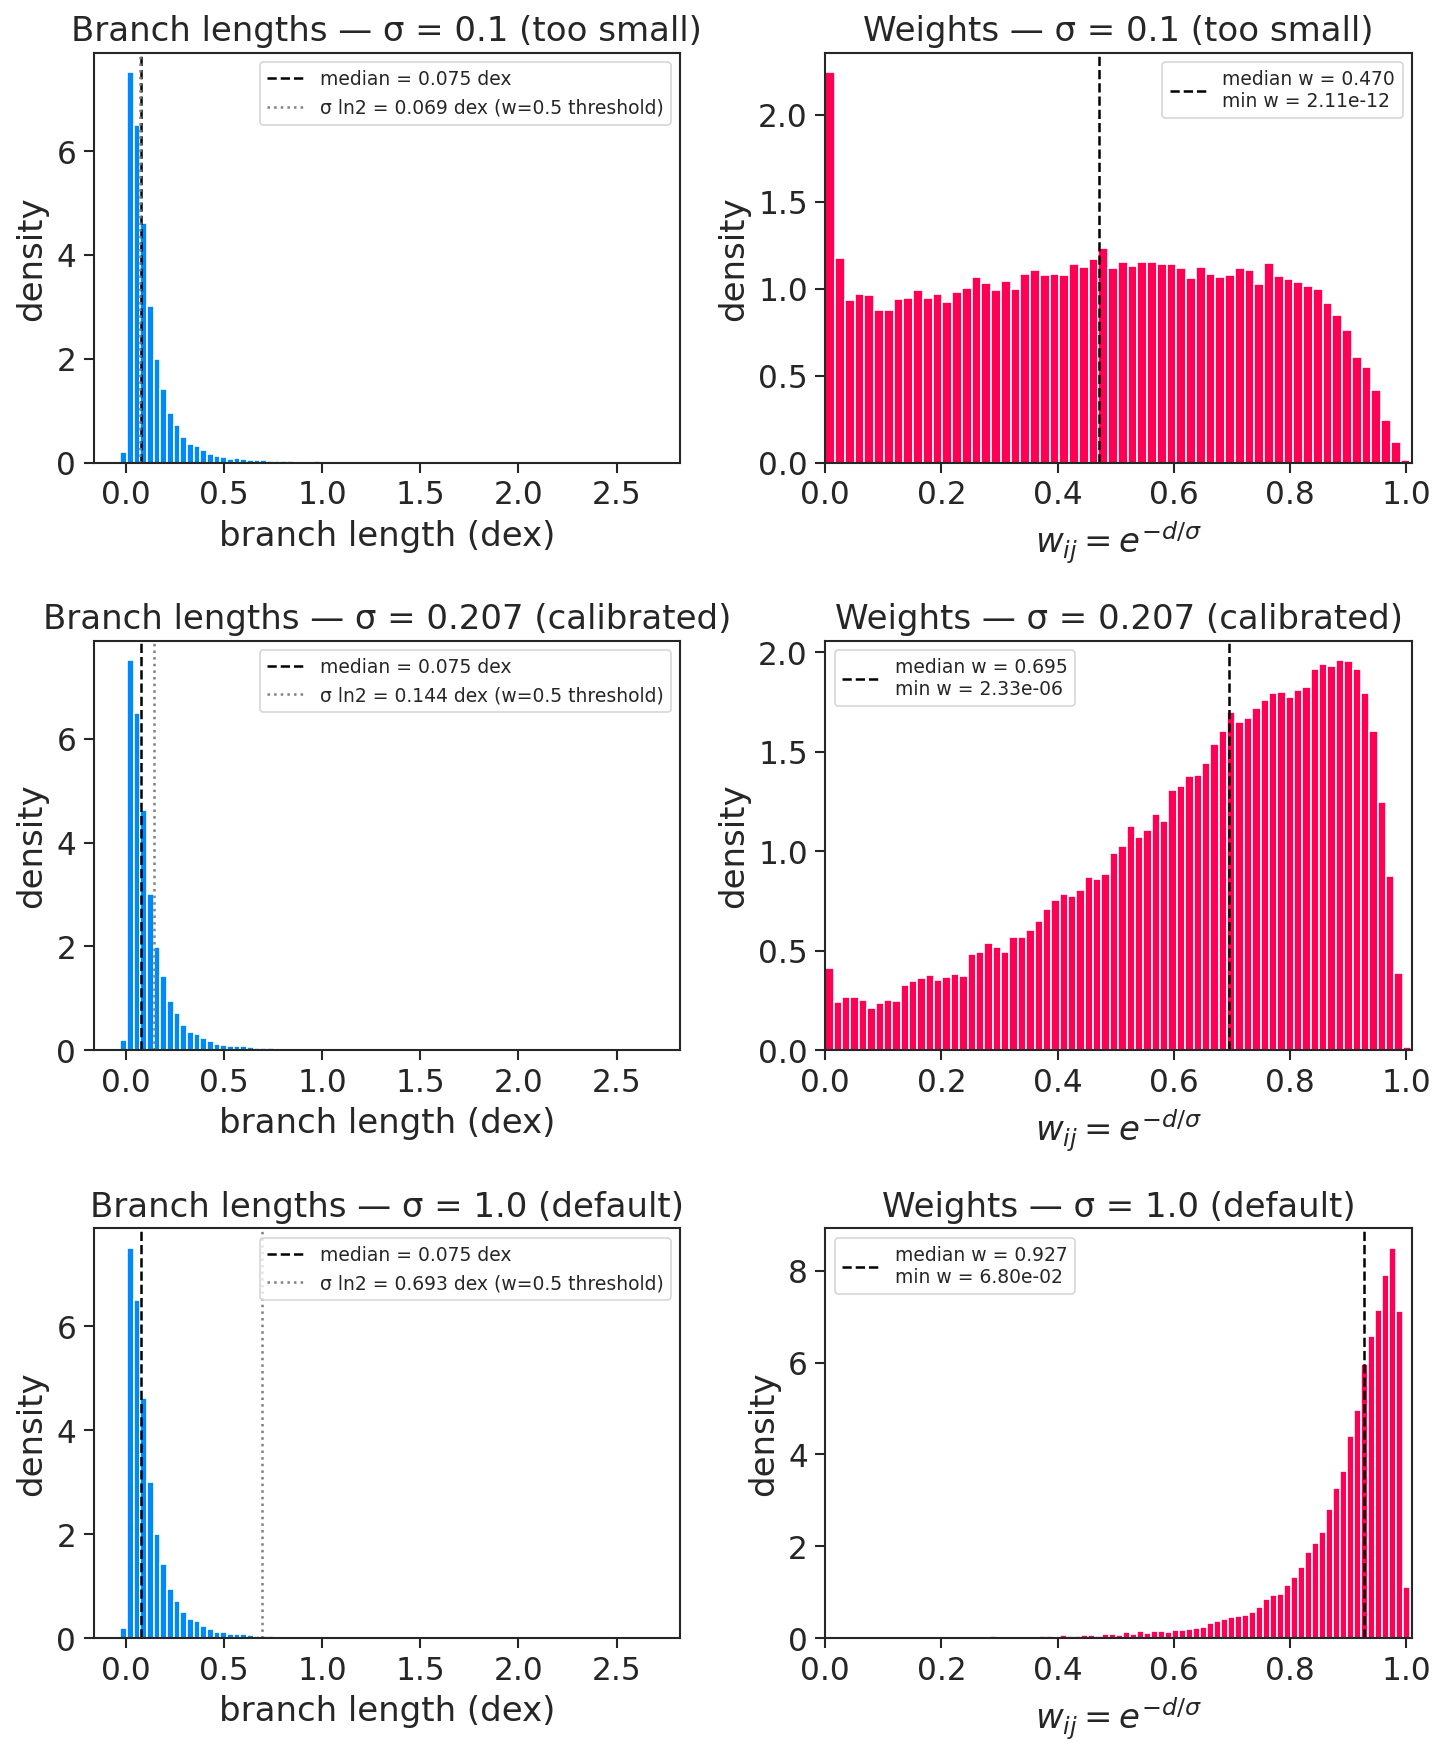

In [ ]:
# ======================================================================
# APPENDIX B.1 — Branch length scale and weight compression
# ======================================================================
# `all_lengths` and `sigma` are already defined in cell 6.
# Here we show the weight distribution for three representative sigma
# values so the compression argument is visual.

SIGMAS_PLOT = [0.1, sigma, 1.0]
sigma_labels = [f"σ = 0.1 (too small)", f"σ = {sigma:.3f} (calibrated)", "σ = 1.0 (default)"]

fig, axes = plt.subplots(len(SIGMAS_PLOT), 2,
                         figsize=(10, 4 * len(SIGMAS_PLOT)), dpi=150)

for row, (s, label) in enumerate(zip(SIGMAS_PLOT, sigma_labels)):
    weights = np.exp(-all_lengths / s)
    ax_d, ax_w = axes[row, 0], axes[row, 1]

    # branch length histogram (same every row, added for visual alignment)
    ax_d.hist(all_lengths, bins=80, color=c0, density=True)
    ax_d.axvline(np.median(all_lengths), color="k", ls="--",
                 label=f"median = {np.median(all_lengths):.3f} dex")
    ax_d.axvline(s * np.log(2), color="grey", ls=":",
                 label=f"σ ln2 = {s * np.log(2):.3f} dex (w=0.5 threshold)")
    ax_d.set_xlabel("branch length (dex)")
    ax_d.set_ylabel("density")
    ax_d.set_title(f"Branch lengths — {label}")
    ax_d.legend(fontsize=9)

    # weight histogram
    ax_w.hist(weights, bins=80, color=c1, density=True)
    ax_w.axvline(np.median(weights), color="k", ls="--",
                 label=f"median w = {np.median(weights):.3f}\nmin w = {weights.min():.2e}")
    ax_w.set_xlabel(r"$w_{ij} = e^{-d/\sigma}$")
    ax_w.set_xlim(0, 1.01)
    ax_w.set_ylabel("density")
    ax_w.set_title(f"Weights — {label}")
    ax_w.legend(fontsize=9)

plt.tight_layout()
# plt.savefig("plots/appendix_weight_compression.png", dpi=300, bbox_inches="tight")
plt.show()


### B.2 — AUC as a function of weight compression (L1/L2 collapse test)

In [ ]:
# ======================================================================
# APPENDIX B.2 — AUC as a function of weight compression
# ----------------------------------------------------------------------
# Hypothesis: AUC depends on HOW MUCH the graph weights are compressed,
# not on the chemical distance metric directly. L1 and L2 differ only by
# changing the branch-length scale, hence the compression at a given sigma.
# If the hypothesis holds, L1 and L2 points fall on the SAME
# AUC-vs-compression curve.
#
# Compression scalar: median weight  w_med = median(exp(-d/sigma)).
#   w_med -> 1  : no compression (kernel flat, weights all ~1)
#   w_med -> 0  : over-compressed (long branches collapse to ~0)
# ======================================================================

def median_weight(all_lengths, s):
    """Compression scalar: median of exp(-d/sigma) over all branch lengths."""
    return float(np.median(np.exp(-all_lengths / s)))

def make_trees(ord, tag):
    """Generate trees for a given distance order; return their dir suffix."""
    cfgs = build_configs(F, dist_ord=ord)
    for cfg in cfgs:
        cfg.out_dir = cfg.out_dir + tag
        pg.generate_trees(cfg)
    return tag

def all_branch_lengths(tag):
    return np.concatenate([
        pg.branch_length_distribution(f"data/history_trees{tag}/{p}.newick")
        for p in ["MW-MW", "GSE-GSE", "Sgr-Sgr"]
    ])

def auc_at_sigma(ord, tree_tag, s):
    """Compute AUC table at compression set by sigma s, for trees in tree_tag."""
    suffix = f"{tree_tag}_s{s:.4f}"
    cfgs = build_configs(F, dist_ord=ord, weight_fn=affinity_kernel(s))
    for cfg in cfgs:
        src = cfg.out_dir + tree_tag
        cfg.out_dir = cfg.out_dir + suffix
        pg.compute_distances(cfg, tree_dir=src)
    panels_s = {
        "MW-GSE":  ("data/history_trees"  + suffix, ["MW-MW",       "GSE-GSE"],         "MW-GSE"),
        "GSE-Sgr": ("data/history_trees"  + suffix, ["GSE-GSE",     "Sgr-Sgr"],         "GSE-Sgr"),
        "MW-Sgr":  ("data/history_trees"  + suffix, ["MW-MW",       "Sgr-Sgr"],         "MW-Sgr"),
        "Nissen":  ("data/nissen20_trees" + suffix, ["Older-Older", "Younger-Younger"], "Older-Younger"),
    }
    return pg.auc_table(panels_s)


In [ ]:
# --- build L1 and L2 trees once, then sweep tau over a compression grid ---
make_trees(ord=1, tag="_l1")
make_trees(ord=2, tag="_l2")

lengths = {"L1": all_branch_lengths("_l1"), "L2": all_branch_lengths("_l2")}

# sweep tau per metric so that w_med spans ~[0.1, 0.95] for BOTH metrics.
# anchoring tau to each metric's own length scale guarantees comparable
# compression coverage despite different absolute branch lengths.
records = []
for metric, ord, tag in [("L1", 1, "_l1"), ("L2", 2, "_l2")]:
    L = lengths[metric]
    med_d = float(np.median(L))
    std_d = float(np.std(L))
    # tau grid: fractions/multiples of the median length
    for frac in [0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.5, 5.0]:
        tau = frac * med_d / np.log(2)
        w = np.exp(-L / tau)
        w_med = float(np.median(w))
        w_std = float(np.std(w))
        auc = auc_at_sigma(ord, tag, tau)
        for measure in ["ASD", "LSD", "NLSD"]:
            for pair in auc.columns:
                records.append(dict(metric=metric, tau=tau,
                                    d_med=med_d, d_std=std_d,
                                    w_med=w_med, w_std=w_std,
                                    measure=measure, pair=pair,
                                    auc=auc.loc[measure, pair]))

sweep_df = pd.DataFrame(records)
sweep_df.to_csv("data/auc_vs_compression.csv", index=False)
print(sweep_df.head())

[MW-GSE] MW: 3436 stars | GSE: 288 stars


[MW-Sgr] MW: 2034 stars | Sgr: 354 stars
[GSE-Sgr] GSE: 288 stars | Sgr: 354 stars
[Nissen] Older: 41 stars | Younger: 29 stars
[MW-GSE] MW: 3436 stars | GSE: 288 stars
[MW-Sgr] MW: 2034 stars | Sgr: 354 stars
[GSE-Sgr] GSE: 288 stars | Sgr: 354 stars
[Nissen] Older: 41 stars | Younger: 29 stars
  metric      tau     d_med     d_std     w_med    w_std measure     pair  \
0     L1  0.01088  0.075411  0.147676  0.000977  0.13445     ASD  GSE-Sgr   
1     L1  0.01088  0.075411  0.147676  0.000977  0.13445     ASD   MW-GSE   
2     L1  0.01088  0.075411  0.147676  0.000977  0.13445     ASD   MW-Sgr   
3     L1  0.01088  0.075411  0.147676  0.000977  0.13445     ASD   Nissen   
4     L1  0.01088  0.075411  0.147676  0.000977  0.13445     LSD  GSE-Sgr   

        auc  
0  0.980612  
1  0.965287  
2  0.578812  
3  0.713387  
4  0.996625  


In [ ]:
sweep_df["w_cv"] = sweep_df["w_std"] / sweep_df["w_med"]

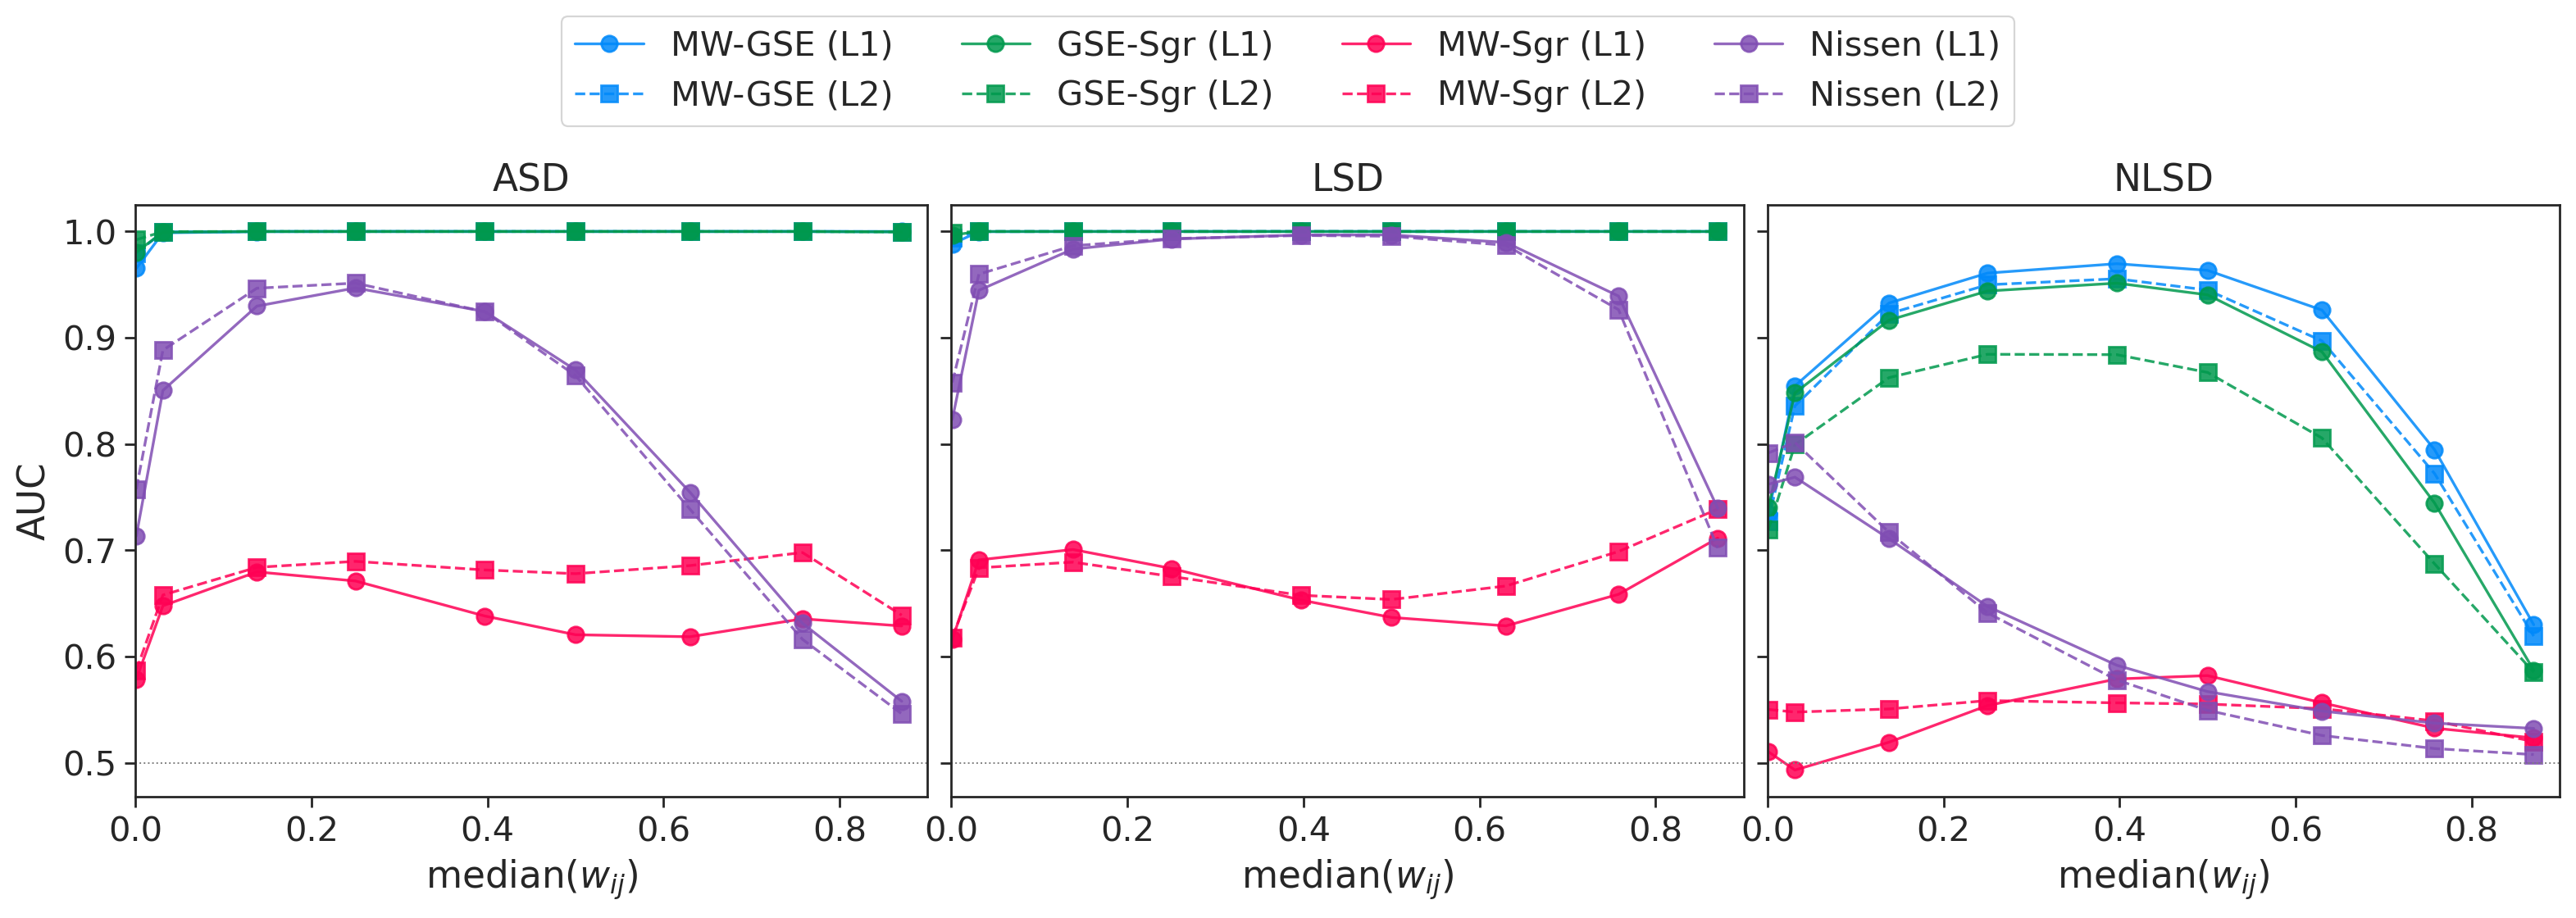


Mean |AUC difference| between L1 and L2 at matched compression:
  ASD  MW-GSE  : 0.002
  ASD  GSE-Sgr : 0.001
  ASD  MW-Sgr  : 0.031
  ASD  Nissen  : 0.017
  LSD  MW-GSE  : 0.001
  LSD  GSE-Sgr : 0.000
  LSD  MW-Sgr  : 0.017
  LSD  Nissen  : 0.012
  NLSD MW-GSE  : 0.016
  NLSD GSE-Sgr : 0.051
  NLSD MW-Sgr  : 0.022
  NLSD Nissen  : 0.020


In [ ]:
# --- AUC vs compression: L1 and L2 should collapse onto one curve ---
# one panel per measure; x = median weight (compression); colour = pair;
# marker/linestyle = metric. Overlap of L1 and L2 = "metric acts via compression".

measures = ["ASD", "LSD", "NLSD"]
pairs = ["MW-GSE", "GSE-Sgr", "MW-Sgr", "Nissen"]
pair_colors = dict(zip(pairs, [c0, c2, c1, (0.5,0.3,0.7)]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=200, sharey=True)
for ax, measure in zip(axes, measures):
    sub = sweep_df[sweep_df.measure == measure]
    for pair in pairs:
        for metric, ls, mk in [("L1", "-", "o"), ("L2", "--", "s")]:
            d = sub[(sub.pair == pair) & (sub.metric == metric)].sort_values("w_med")
            ax.plot(d.w_med, d.auc, ls=ls, marker=mk, color=pair_colors[pair],
                    label=f"{pair} ({metric})", markersize=7, alpha=.85)
    ax.axhline(0.5, color="grey", lw=.7, ls=":")
    ax.set_title(measure)
    ax.set_xlabel(r"$\mathrm{median}(w_{ij})$")
    ax.set_xlim(0, .9)
axes[0].set_ylabel("AUC")
# de-duplicate legend (pair colours; metric shown by linestyle)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles[:len(pairs)*2], labels[:len(pairs)*2],
           ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.15))
fig.tight_layout()
fig.subplots_adjust(wspace=0.03)
fig.savefig("plots/appendix_auc_vs_compression.png", dpi=300, bbox_inches="tight")
plt.show()

# quantify the collapse: for each (measure,pair), interpolate L2 onto L1's
# w_med grid and report the mean |AUC_L1 - AUC_L2| at matched compression.
print("\nMean |AUC difference| between L1 and L2 at matched compression:")
for measure in measures:
    for pair in pairs:
        s = sweep_df[(sweep_df.measure==measure) & (sweep_df.pair==pair)]
        l1 = s[s.metric=="L1"].sort_values("w_med")
        l2 = s[s.metric=="L2"].sort_values("w_med")
        if len(l1) and len(l2):
            interp = np.interp(l1.w_med, l2.w_med, l2.auc)
            print(f"  {measure:4s} {pair:8s}: {np.mean(np.abs(l1.auc.values - interp)):.3f}")


In [ ]:
def spread_measure(L, tau, kind="mad_median"):
    w = np.exp(-L / tau)
    med = np.median(w)
    if kind == "std_median":  return np.std(w)/ med
    if kind == "mad_median":  return np.median(np.abs(w - med)) / med
    if kind == "iqr_median":
        q1, q3 = np.percentile(w, [25, 75]); return (q3 - q1) / med
    if kind == "gini":
        ws = np.sort(w); n = len(ws); idx = np.arange(1, n+1)
        return (2*np.sum(idx*ws)/(n*np.sum(ws))) - (n+1)/n

for kind in ["std_median", "mad_median", "gini"]:
    sweep_df[kind] = sweep_df.apply(
        lambda r: float(spread_measure(lengths[r["metric"]], r["tau"], kind)), axis=1)

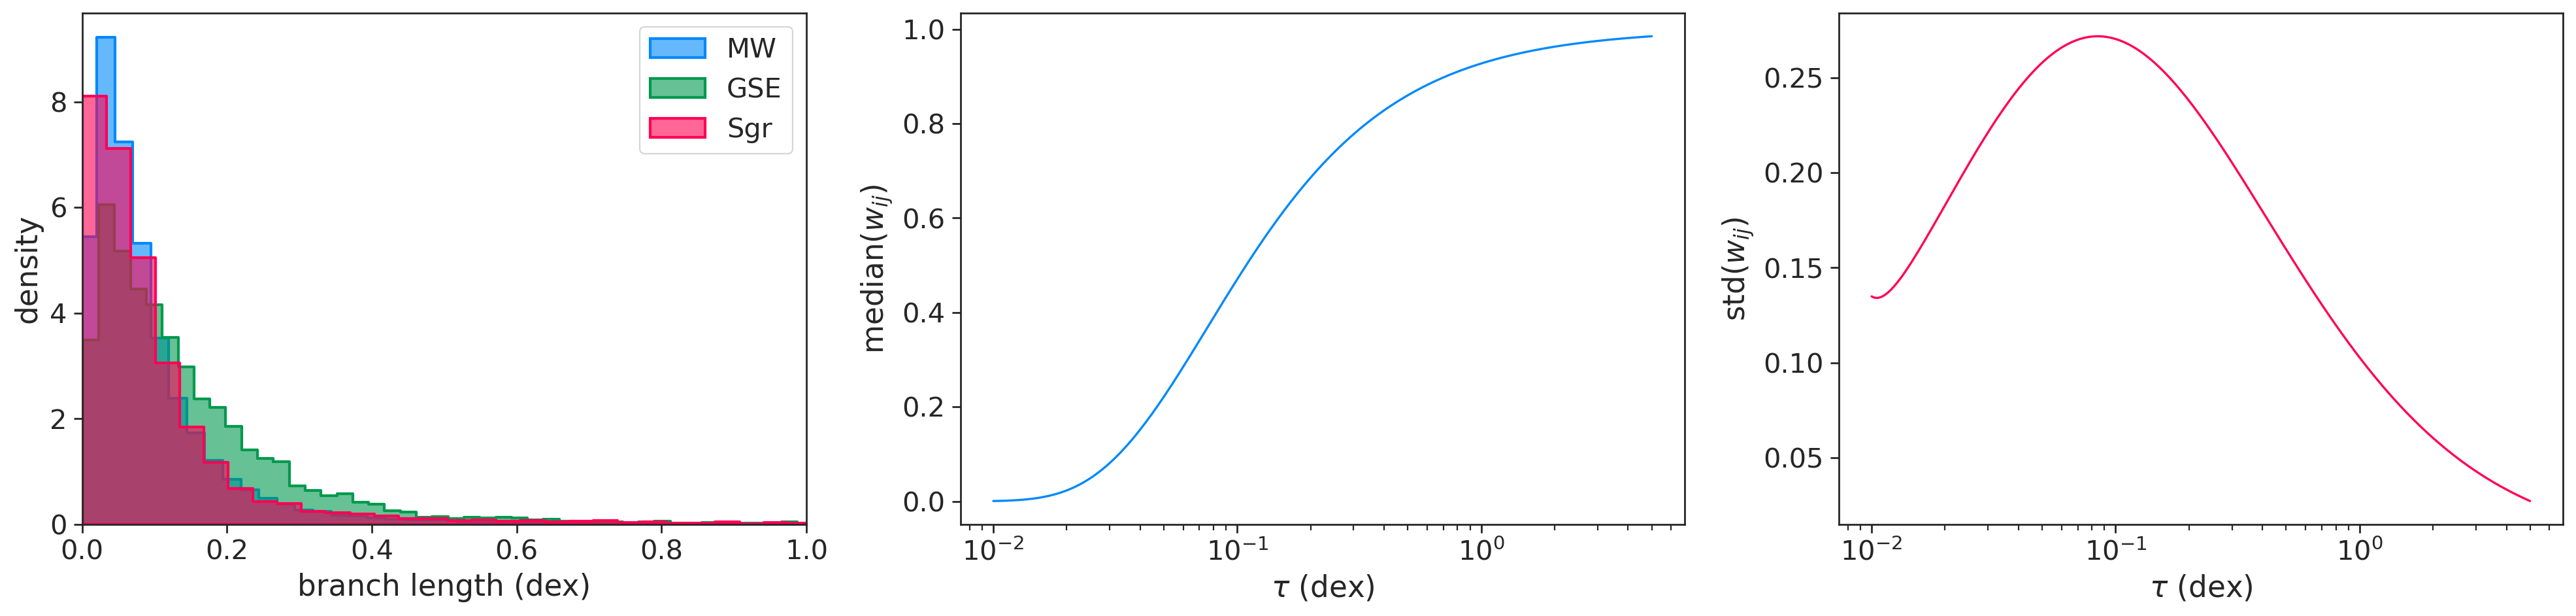

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=200)

# left: branch length histograms, L1 trees, one population at a time
for label, color in zip(["MW-MW", "GSE-GSE", "Sgr-Sgr"], [c0, c2, c1]):
    L = pg.branch_length_distribution(f"data/history_trees_l1/{label}.newick")
    sns.histplot(L, bins=80, stat="density", element="step", lw=1.5,
                color=color, label=label.split("-")[0],ax=axes[0],alpha=0.6)

axes.set_xlabel("branch length (dex)"); axes[0].set_ylabel("density")
axes[0].set_xlim(0, 1.0); axes[0].legend()

# (b) median weight vs tau
tau_grid = np.geomspace(0.01, 5.0, 200)
axes[1].plot(tau_grid, [median_weight(lengths["L1"], t) for t in tau_grid], color=c0)
# axes[1].axvline(0.1, color="k", ls="--", lw=1, label=r"adopted $\tau=0.2$")
# axes[1].axhline(median_weight(lengths["L1"], 0.1), color="grey", ls=":", lw=1)
axes[1].set_xscale("log"); axes[1].set_xlabel(r"$\tau$ (dex)")
axes[1].set_ylabel(r"$\mathrm{median}(w_{ij})$")

# (c) spread of weights vs tau (non-monotonic: rises then falls)
w_std_curve = [float(np.std(np.exp(-lengths["L1"] / t))) for t in tau_grid]
axes[2].plot(tau_grid, w_std_curve, color=c1)
axes[2].set_xscale("log"); axes[2].set_xlabel(r"$\tau$ (dex)")
axes[2].set_ylabel(r"$\mathrm{std}(w_{ij})$")

fig.tight_layout()
fig.savefig("plots/appendix_branchlengths_wmed.png", dpi=300, bbox_inches="tight")
plt.show()

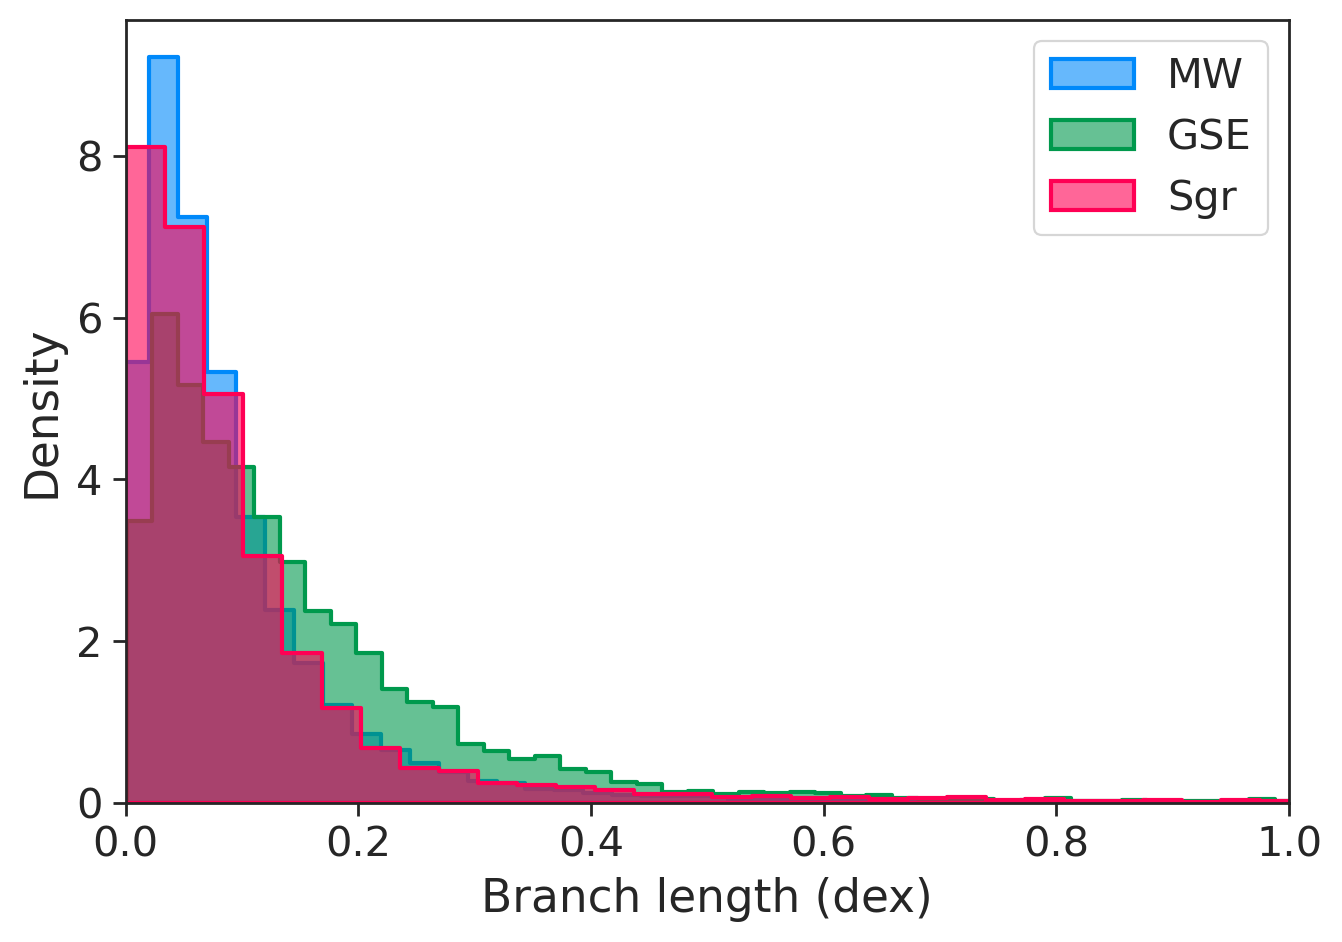

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5), dpi=200)

# left: branch length histograms, L1 trees
for label, color in zip(["MW-MW", "GSE-GSE", "Sgr-Sgr"], [c0, c2, c1]):
    L = pg.branch_length_distribution(f"data/history_trees_l1/{label}.newick")
    sns.histplot(L, bins=80, stat="density", element="step", lw=1.5,
                 color=color, label=label.split("-")[0], ax=axes, alpha=0.6)
axes.set_xlabel("Branch length (dex)"); axes.set_ylabel("Density")
axes.set_xlim(0, 1.0); axes.legend()

fig.tight_layout()
fig.savefig("plots/appendix_branchlengths.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5), dpi=200)

# left: branch length histograms, L1 trees
for label, color in zip(["MW-MW", "GSE-GSE", "Sgr-Sgr"], [c0, c2, c1]):
    L = pg.branch_length_distribution(f"data/history_trees_l1/{label}.newick")
    sns.histplot(L, bins=80, stat="density", element="step", lw=1.5,
                 color=color, label=label.split("-")[0], ax=axes[0], alpha=0.6)
axes[0].set_xlabel("branch length (dex)"); axes[0].set_ylabel("density")
axes[0].set_xlim(0, 1.0); axes[0].legend()

# right: relative spread std/median vs tau
tau_grid = np.geomspace(0.01, 5.0, 200)
spread_curve = [
    float(np.std(np.exp(-lengths["L1"] / t)) / np.median(np.exp(-lengths["L1"] / t)))
    for t in tau_grid
]
axes[1].plot(tau_grid, spread_curve, color=c0)
axes[1].set_xscale("log")
axes[1].set_yscale("log")     # std/median spans a large range -> log y
axes[1].set_xlabel(r"$\tau$ (dex)")
axes[1].set_ylabel(r"$\mathrm{std}(w_{ij})\,/\,\mathrm{median}(w_{ij})$")
axes.del
fig.tight_layout()
fig.savefig("plots/appendix_branchlengths.png", dpi=300, bbox_inches="tight")
plt.show()

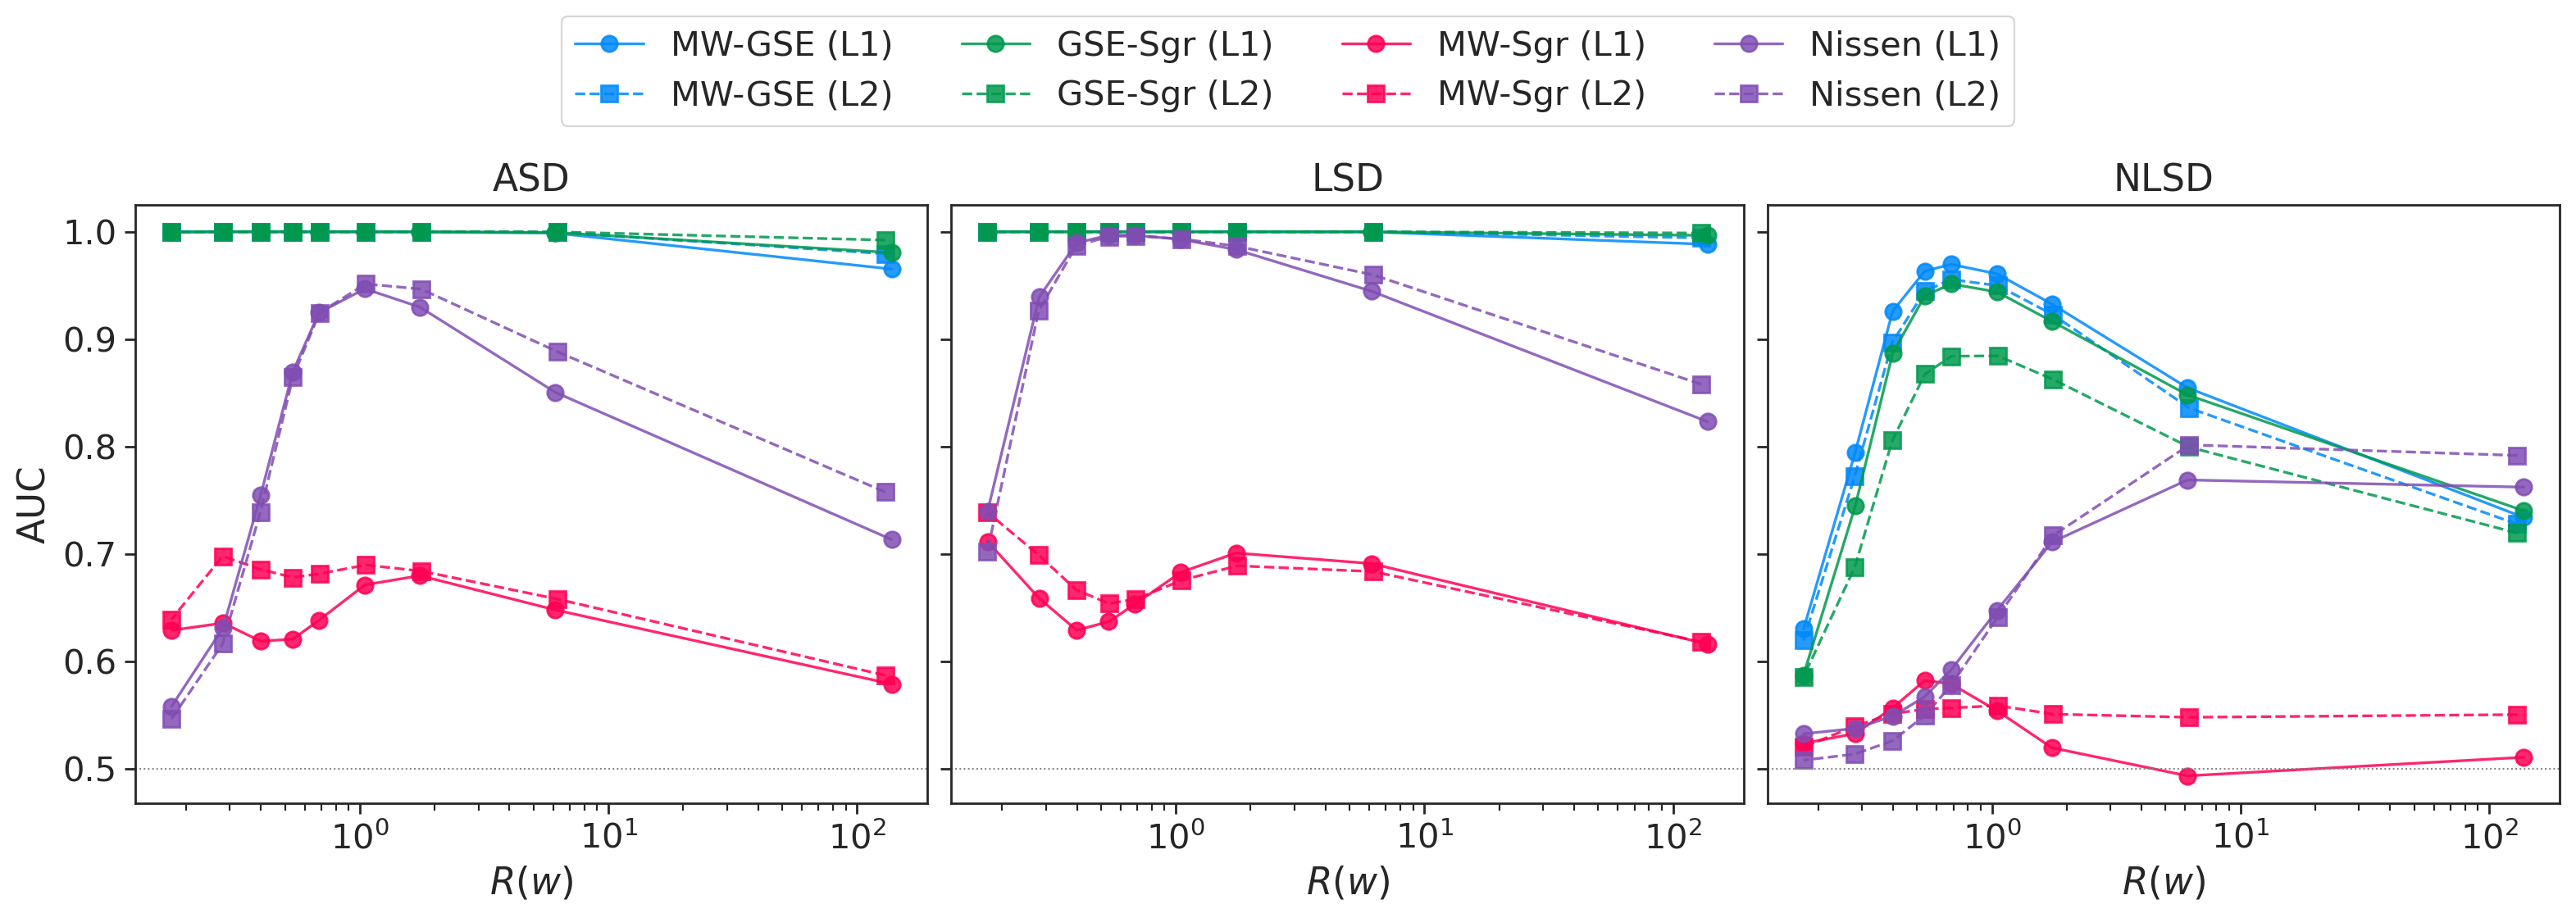

In [ ]:
measures = ["ASD", "LSD", "NLSD"]
pairs = ["MW-GSE", "GSE-Sgr", "MW-Sgr", "Nissen"]
pair_colors = dict(zip(pairs, [c0, c2, c1, (0.5, 0.3, 0.7)]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=200, sharey=True)
for ax, measure in zip(axes, measures):
    sub = sweep_df[sweep_df.measure == measure]
    for pair in pairs:
        for metric, ls, mk in [("L1", "-", "o"), ("L2", "--", "s")]:
            d = sub[(sub.pair == pair) & (sub.metric == metric)].sort_values("tau")  # sort by tau, not w_cv
            ax.plot(d.w_cv, d.auc, ls=ls, marker=mk, color=pair_colors[pair],
                    label=f"{pair} ({metric})", markersize=7, alpha=.85)
    ax.axhline(0.5, color="grey", lw=.7, ls=":")
    ax.set_title(measure)
    ax.set_xlabel(r"$R(w)$")
    ax.set_xscale("log")
axes[0].set_ylabel("AUC")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles[:len(pairs)*2], labels[:len(pairs)*2],
           ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.15))
fig.tight_layout()
fig.subplots_adjust(wspace=0.03)
fig.savefig("plots/appendix_auc_vs_spread.png", dpi=300, bbox_inches="tight")
plt.show()

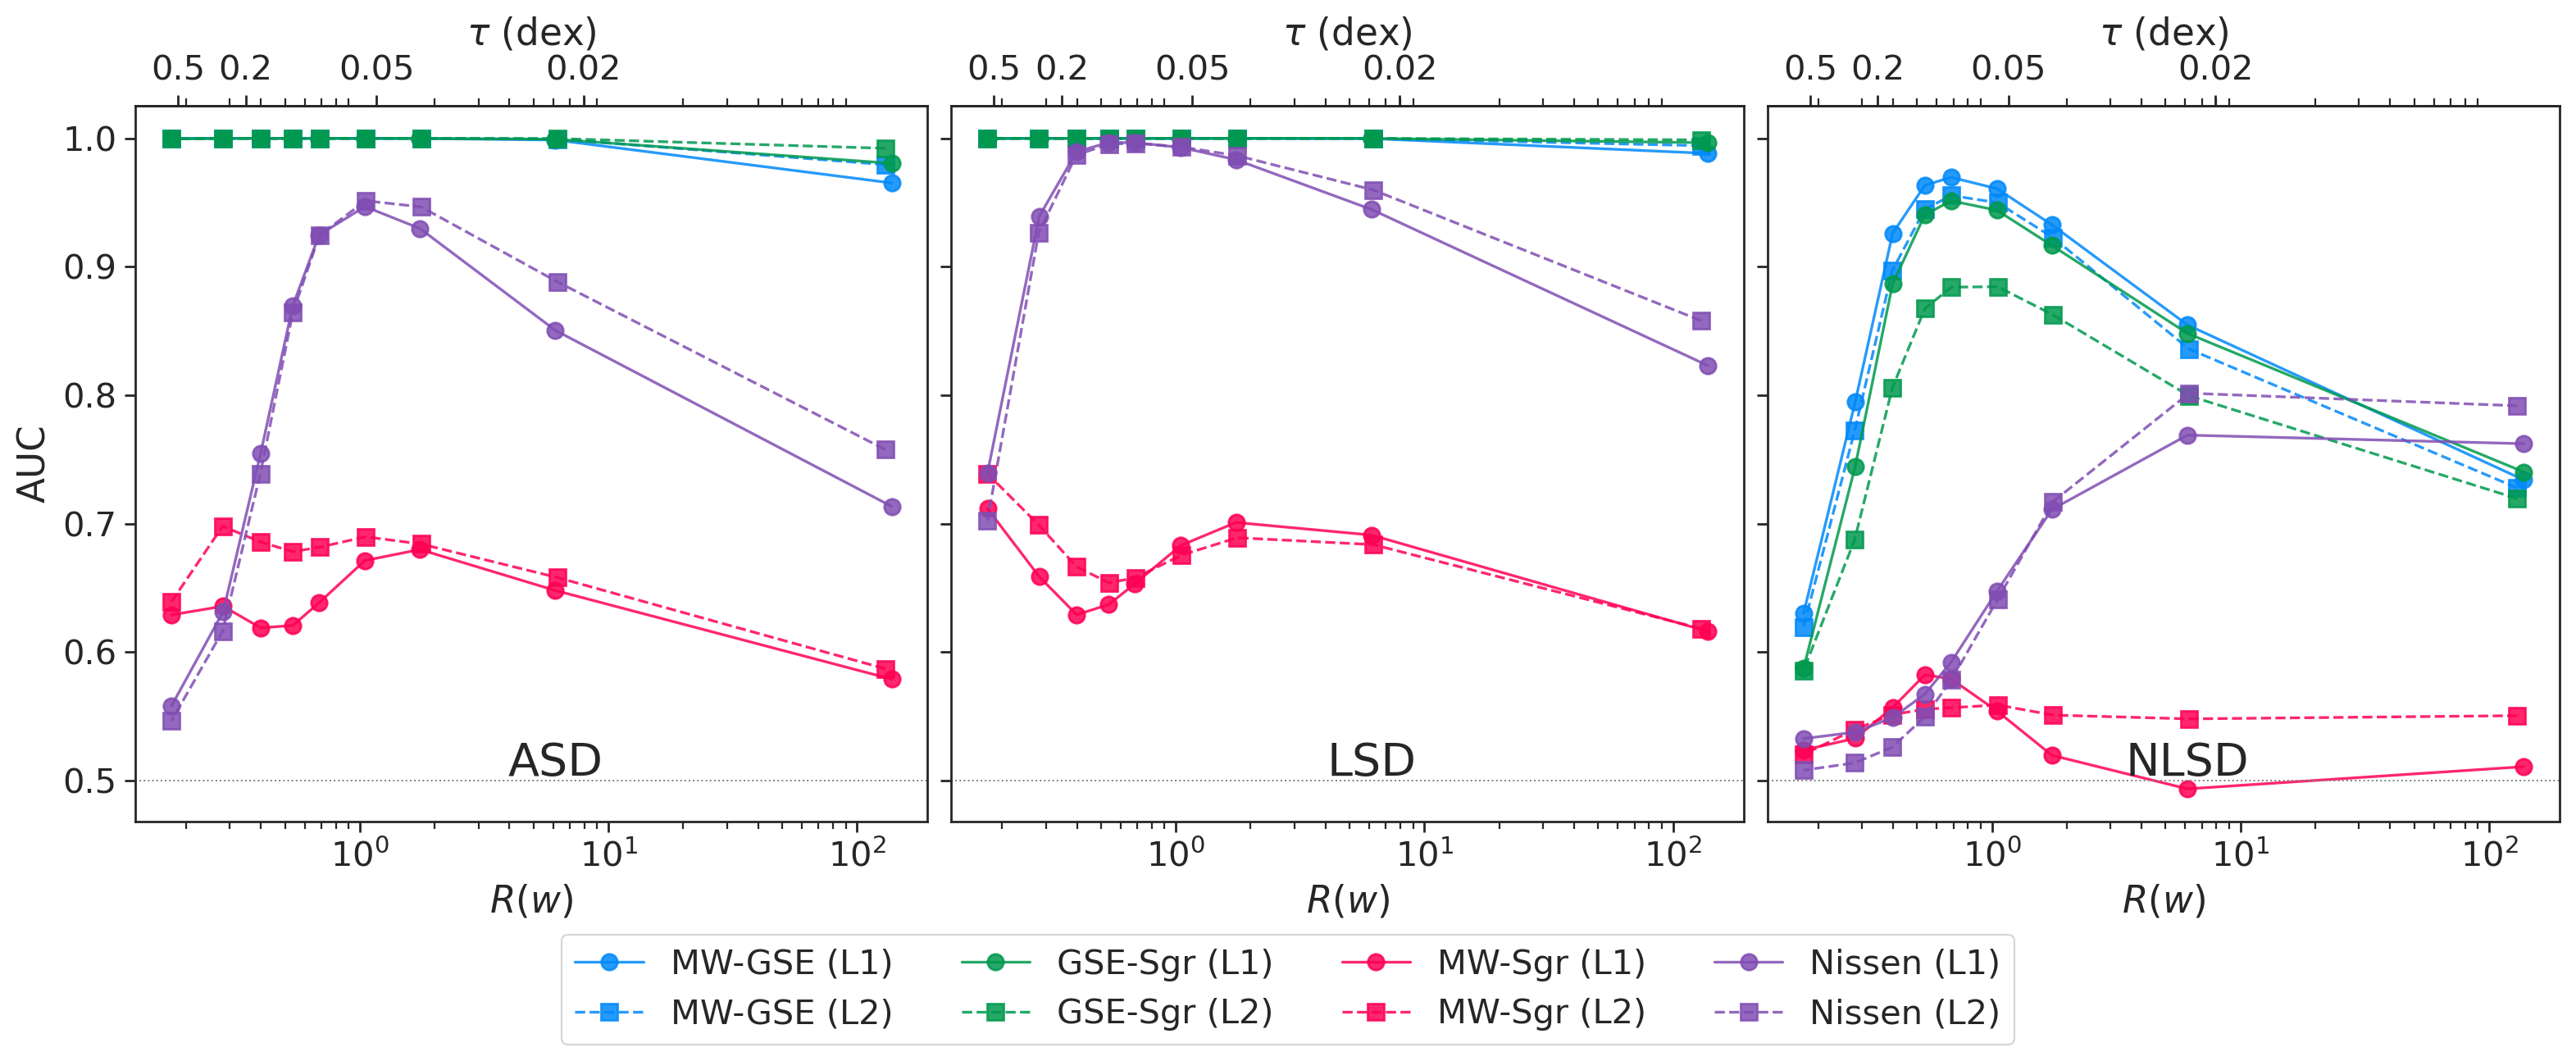

In [ ]:
measures = ["ASD", "LSD", "NLSD"]
pairs = ["MW-GSE", "GSE-Sgr", "MW-Sgr", "Nissen"]
pair_colors = dict(zip(pairs, [c0, c2, c1, (0.5, 0.3, 0.7)]))

# --- build the (monotonic) tau <-> std/median mapping from L1 branch lengths ---
tau_grid = np.geomspace(0.01, 5.0, 400)
spread_grid = np.array([
    np.std(np.exp(-lengths["L1"] / t)) / np.median(np.exp(-lengths["L1"] / t))
    for t in tau_grid
])
# spread decreases as tau increases -> reverse both so np.interp sees increasing x
order = np.argsort(spread_grid)
spread_sorted, tau_sorted = spread_grid[order], tau_grid[order]
def spread_to_tau(s):              # invert mapping for tick placement
    return np.interp(s, spread_sorted, tau_sorted)
def tau_to_spread(t):
    return np.interp(t, tau_grid, spread_grid)

tau_ticks = np.array([0.02, 0.05, 0.2, 0.5, 1.0, 2.0])
tau_tick_pos = tau_to_spread(tau_ticks)
tau02_pos = tau_to_spread(np.array([0.2]))[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 6), dpi=200, sharey=True)
for ax, measure in zip(axes, measures):
    sub = sweep_df[sweep_df.measure == measure]
    for pair in pairs:
        for metric, ls, mk in [("L1", "-", "o"), ("L2", "--", "s")]:
            d = sub[(sub.pair == pair) & (sub.metric == metric)].sort_values("tau")
            ax.plot(d.w_cv, d.auc, ls=ls, marker=mk, color=pair_colors[pair],
                    label=f"{pair} ({metric})", markersize=7, alpha=.85)
    ax.axhline(0.5, color="grey", lw=.7, ls=":")
    #ax.axvline(tau02_pos, color="k", ls="--", lw=1, alpha=.7)   # adopted tau=0.2
    #ax.set_title(measure)
    ax.set_title("")   # remove the title
    ax.text(0.53, 0.05, measure, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=20)
    ax.set_xlabel(r"$R(w)$")    
    ax.set_xscale("log")

    # secondary top axis labelled in tau
    secax = ax.secondary_xaxis("top")
    secax.set_xticks(tau_tick_pos)
    secax.set_xticklabels([f"{t:g}" for t in tau_ticks])
    secax.set_xlabel(r"$\tau$ (dex)")


    
    
axes[0].set_ylabel("AUC")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles[:len(pairs)*2], labels[:len(pairs)*2],
           ncol=4, loc="center", bbox_to_anchor=(0.5, -.03))
fig.tight_layout()
fig.subplots_adjust(wspace=0.03)
fig.savefig("plots/appendix_auc_vs_spread.png", dpi=300, bbox_inches="tight")
plt.show()


